### Download a Google Drive file by ID

To download a specific file from Google Drive using its ID, you can use the `gdown` library. You'll need to extract the file ID from the sharing link.

In [1]:
!pip install gdown

# The file ID is the part after 'id/' in the URL
# For your link 'https://drive.google.com/file/d/1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm/view?usp=sharing',
# the file ID is '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'

gdrive_file_id = '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'
output_filename = 'monreader_data.zip' # Or whatever the file type is, e.g., 'data.zip'

!gdown --id {gdrive_file_id} -O {output_filename}

print(f"File '{output_filename}' downloaded to your Colab environment.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm
From (redirected): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm&confirm=t&uuid=e298cfd0-e821-46c6-b95a-caba5ee4c7aa
To: /content/monreader_data.zip
100% 940M/940M [00:16<00:00, 55.5MB/s]
File 'monreader_data.zip' downloaded to your Colab environment.


In [2]:
import zipfile

with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall('extracted_folder')
print(f"Extracted '{output_filename}' to 'extracted_folder'.")

Extracted 'monreader_data.zip' to 'extracted_folder'.


### Data Exploration: Image Counts, Dimensions, and Samples

Let's start by exploring the extracted dataset to understand its structure. We'll count the number of images in each category (flip/notflip), examine their dimensions, and display a few sample images.

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

base_dir_training = 'extracted_folder/images/training'
notflip_dir_train = os.path.join(base_dir_training, 'notflip')
flip_dir_train = os.path.join(base_dir_training, 'flip')

# --- 1. Count images ---
notflip_images_training = [os.path.join(notflip_dir_train, f) for f in os.listdir(notflip_dir_train) if f.endswith(('.jpg'))]
flip_images_training = [os.path.join(flip_dir_train, f) for f in os.listdir(flip_dir_train) if f.endswith(('.jpg'))]

base_dir_testing = 'extracted_folder/images/testing'
notflip_dir_test = os.path.join(base_dir_testing, 'notflip')
flip_dir_test = os.path.join(base_dir_testing, 'flip')

notflip_images_testing = [os.path.join(notflip_dir_test, f) for f in os.listdir(notflip_dir_test) if f.endswith(('.jpg'))]
flip_images_testing = [os.path.join(flip_dir_test, f) for f in os.listdir(flip_dir_test) if f.endswith(('.jpg'))]
print(f"Number of 'notflip' images in training: {len(notflip_images_training)}")
print(f"Number of 'flip' images in training: {len(flip_images_training)}")
print(f"Total images in training: {len(notflip_images_training) + len(flip_images_training)}")

# Corrected print statements for testing set
print(f"Number of 'notflip' images in testing: {len(notflip_images_testing)}")
print(f"Number of 'flip' images in testing: {len(flip_images_testing)}")
print(f"Total images in testing: {len(notflip_images_testing) + len(flip_images_testing)}")

Number of 'notflip' images in training: 1230
Number of 'flip' images in training: 1162
Total images in training: 2392
Number of 'notflip' images in testing: 307
Number of 'flip' images in testing: 290
Total images in testing: 597


In [4]:
from PIL import Image
# --- 2. Check image dimensions ---
notflip_image_path = notflip_images_training[0]
with Image.open(notflip_image_path) as notflip_image:
 print(f"\nSample image dimensions (notflip image size): {notflip_image.size} (width, height)")
 print(f"Sample image mode: {notflip_image.mode}") # e.g., RGB, L
 flip_image_path = flip_images_training[0]
with Image.open(flip_image_path) as flip_image:
 print(f"\nSample image dimensions (flip image size): {flip_image.size} (width, height)")
 print(f"Sample image mode: {flip_image.mode}") # e.g., RGB, L


Sample image dimensions (notflip image size): (1080, 1920) (width, height)
Sample image mode: RGB

Sample image dimensions (flip image size): (1080, 1920) (width, height)
Sample image mode: RGB



Displaying sample images...


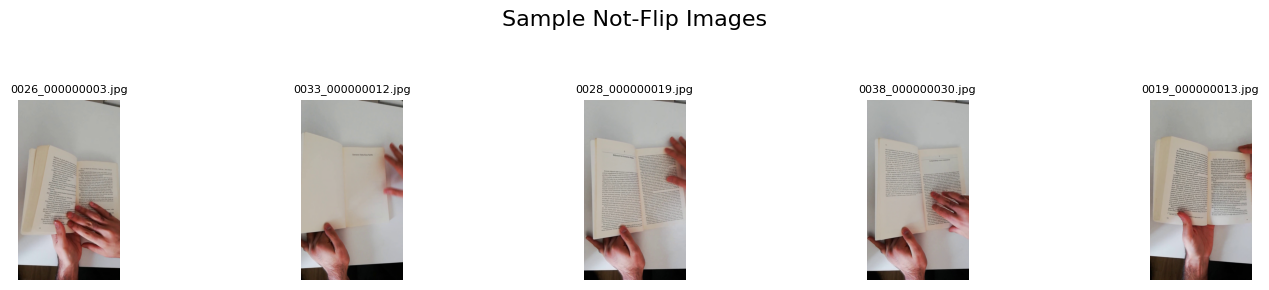

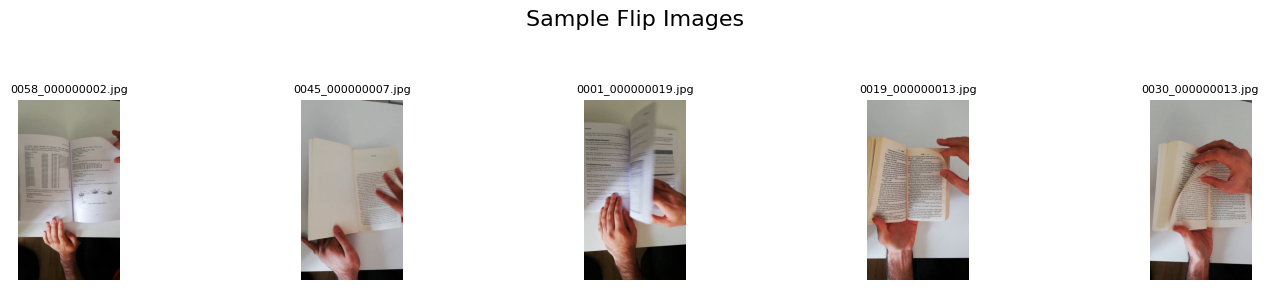

In [5]:
# --- 3. Display sample images ---
print("\nDisplaying sample images...")

def display_samples(image_paths, title, num_samples=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(np.random.choice(image_paths, num_samples, replace=False)):
        plt.subplot(1, num_samples, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

if notflip_images_training:
    display_samples(notflip_images_training, 'Sample Not-Flip Images')

if flip_images_training:
    display_samples(flip_images_training, 'Sample Flip Images')


In [6]:
import os
from PIL import Image
import numpy as np

# Training folders
base_dir_training = 'extracted_folder/images/training'

# Testing folders
base_dir_testing = 'extracted_folder/images/testing'

# Function to load images and labels
def load_data(base_dir):
    X = []
    y = []

    classes = ['flip', 'notflip']

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(base_dir, class_name)

        for file_name in os.listdir(class_dir):
            if file_name.endswith('.jpg'):
                img_path = os.path.join(class_dir, file_name)

                # Open image
                img = Image.open(img_path).convert('RGB')

                # Resize image
                img = img.resize((224, 224))

                # Convert image to numpy array
                img_array = np.array(img)

                X.append(img_array)
                y.append(label)

    return np.array(X), np.array(y)

# Create datasets
X_train, y_train = load_data(base_dir_training)
X_test, y_test = load_data(base_dir_testing)
X_train= X_train/255.0
X_test= X_test/255.0

# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2392, 224, 224, 3)
y_train shape: (2392,)
X_test shape: (597, 224, 224, 3)
y_test shape: (597,)


In [7]:
X_train[1,:]

array([[[0.64313725, 0.63921569, 0.62745098],
        [0.64313725, 0.65490196, 0.63921569],
        [0.64313725, 0.65882353, 0.64313725],
        ...,
        [0.57647059, 0.59215686, 0.59607843],
        [0.58431373, 0.58823529, 0.57647059],
        [0.59607843, 0.6       , 0.56470588]],

       [[0.65098039, 0.65098039, 0.64705882],
        [0.63921569, 0.65490196, 0.64705882],
        [0.63921569, 0.65882353, 0.64705882],
        ...,
        [0.53333333, 0.54509804, 0.56078431],
        [0.5372549 , 0.54901961, 0.55294118],
        [0.54117647, 0.54901961, 0.54117647]],

       [[0.65098039, 0.64313725, 0.6627451 ],
        [0.63137255, 0.64705882, 0.65882353],
        [0.63921569, 0.64705882, 0.6627451 ],
        ...,
        [0.50588235, 0.52156863, 0.54117647],
        [0.50980392, 0.5254902 , 0.5372549 ],
        [0.51764706, 0.53333333, 0.5372549 ]],

       ...,

       [[0.01176471, 0.01176471, 0.01176471],
        [0.01176471, 0.01176471, 0.01176471],
        [0.00784314, 0

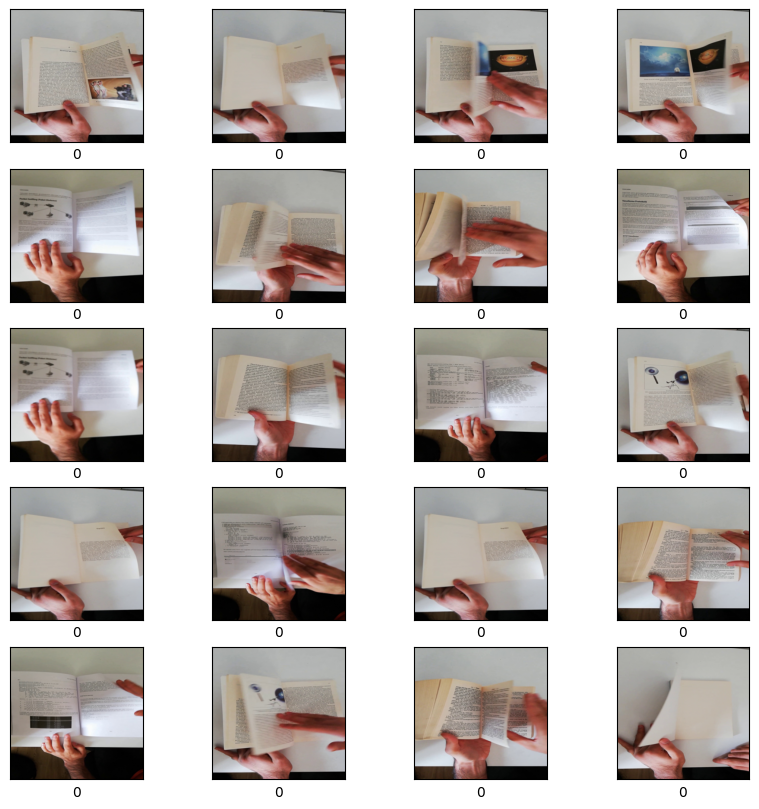

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])

    plt.xlabel(y_train[i])
plt.show()


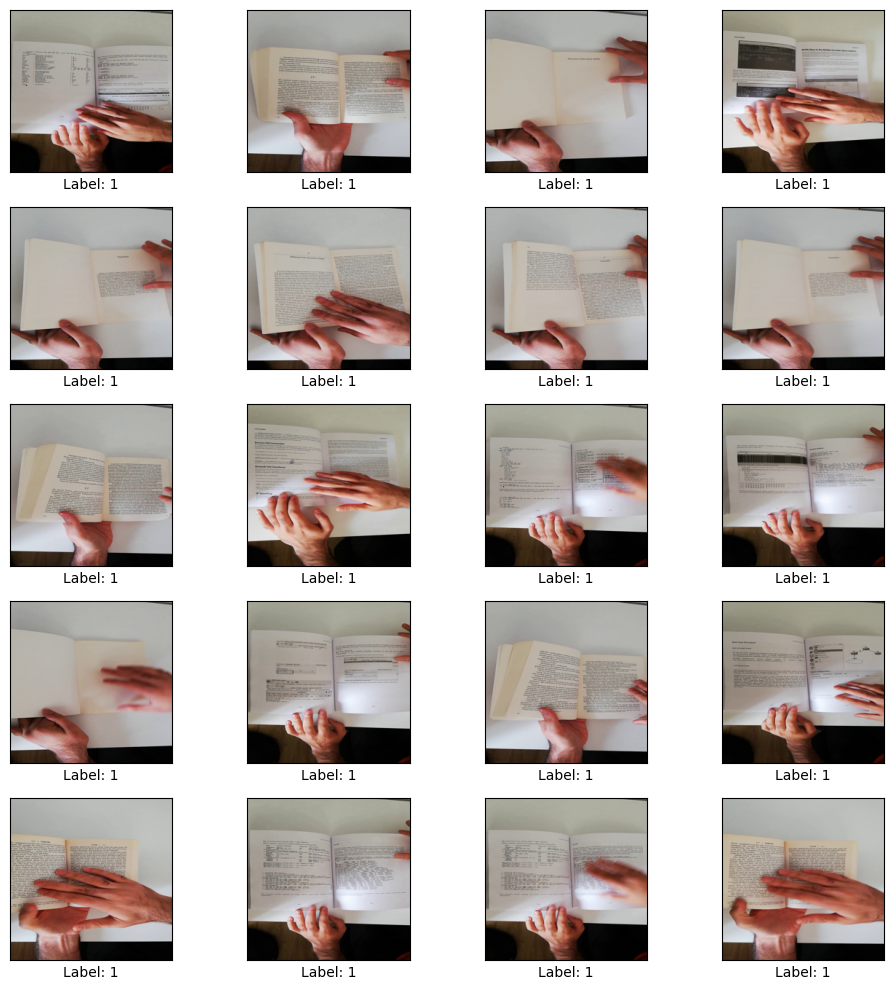

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

num_images_to_display = 20
total_images = len(X_train)

# Ensure there are enough images to display the last 20
if total_images < num_images_to_display:
    print(f"Not enough images in X_train ({total_images}) to display the last {num_images_to_display}.")
else:
    start_index = total_images - num_images_to_display

    # Define grid for 20 images (e.g., 5 rows, 4 columns)
    grid_rows = 5
    grid_cols = 4

    for j in range(num_images_to_display):
        current_image_index = start_index + j
        plt.subplot(grid_rows, grid_cols, j + 1) # j+1 for subplot position (1-indexed)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(X_train[current_image_index]) # X_train should be in (H, W, C) format
        # y_train contains integer labels (0 or 1)
        plt.xlabel(f"Label: {y_train[current_image_index]}")
    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

In [10]:
y_train= y_train.reshape(len(y_train), 1)
y_test= y_test.reshape(len(y_test), 1)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2392, 224, 224, 3)
(597, 224, 224, 3)
(2392, 1)
(597, 1)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model= Sequential()
model.add(Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9783 - loss: 0.0857 - val_accuracy: 0.9849 - val_loss: 0.0501
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9975 - loss: 0.0118 - val_accuracy: 0.9916 - val_loss: 0.0444
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.9996 - loss: 0.0045 - val_accuracy: 0.9883 - val_loss: 0.0430
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9883 - val_loss: 0.0344
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 1.0000 - loss: 5.6430e-04 - val_accuracy: 0.9899 - val_loss: 0.0400


In [20]:
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy:', test_acc)

19/19 - 13s - 661ms/step - accuracy: 0.9899 - loss: 0.0400

Test accuracy: 0.9899497628211975


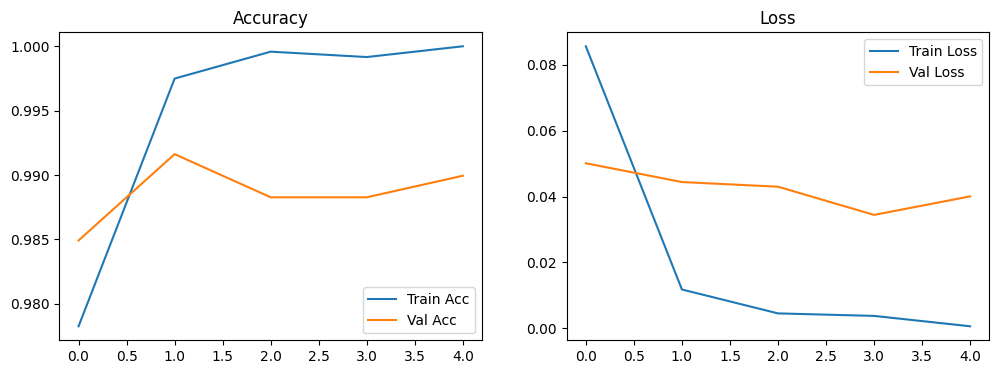

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 910ms/step


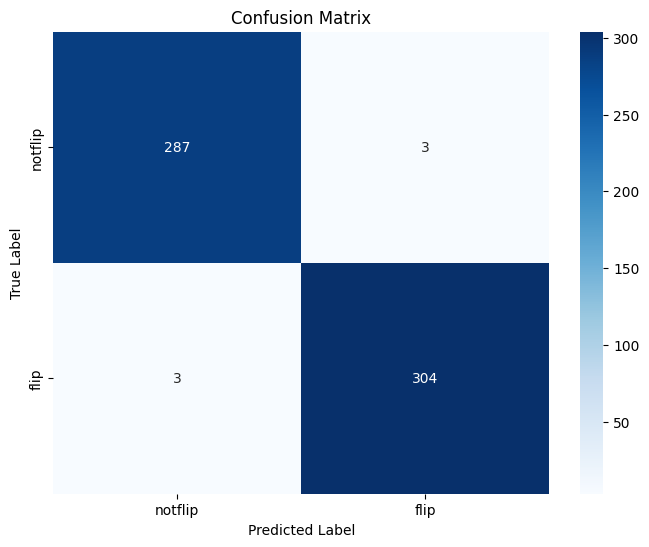

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (y_pred_proba > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define class labels for better readability
class_labels = ['notflip', 'flip']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()